# Modules 

In [2]:
#from Modules import *
import numpy as np
from tp_perceptron_source import (rand_gauss, rand_bi_gauss, rand_checkers,
                                  rand_clown, plot_2d, gradient,
                                  plot_gradient, frontiere_new,
                                  hinge_loss, gr_hinge_loss,
                                  mse_loss, zero_one_loss, gr_mse_loss)
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns

In [3]:
# Plot
plt.close('all')
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Computer Modern Roman']})
params = {'axes.labelsize': 12,
          'font.size': 16,
          'legend.fontsize': 16,
          'text.usetex': False,
          'figure.figsize': (8, 6)}
plt.rcParams.update(params)
# Seaborn
sns.set_context("poster")
sns.set_palette("colorblind")
sns.set_style("white")
sns.axes_style()
# Seed initialization
np.random.seed(seed=44)
# For saving files
saving_activated = True # False

# 1. Analyses des fonctions de génération de données 

## 1.1. rand_gauss

Nous avons ici la fonction rand_gauss. Elle permet de générer une donnée contenant : 
- 100 observations,
- des moyennes de deux dimensions X et Y égales respectivement à 1
- des écarts-types égaaux à 1
- res est la taille des données crées. n son nombre de ligne et d son nombre de colonnes 
- d est égal à la longueur du vecteur mu. Dans notre cas, d est égal à 2 car mu=[1, 1]
- la dernière ligne signifie qu'on bascule le centre de la distribution de (0,0) à la spécification de la moyenne et correspondre les écarts-types aussi à ce qu'on veut.

## 1.2. Représentation graphique des fonctions 

### 1.2.1 rand_bi_gauss uniquement

#### 1.2.1.1 Simulation du changement des écarts-types

X1 (40, 2) (40,)


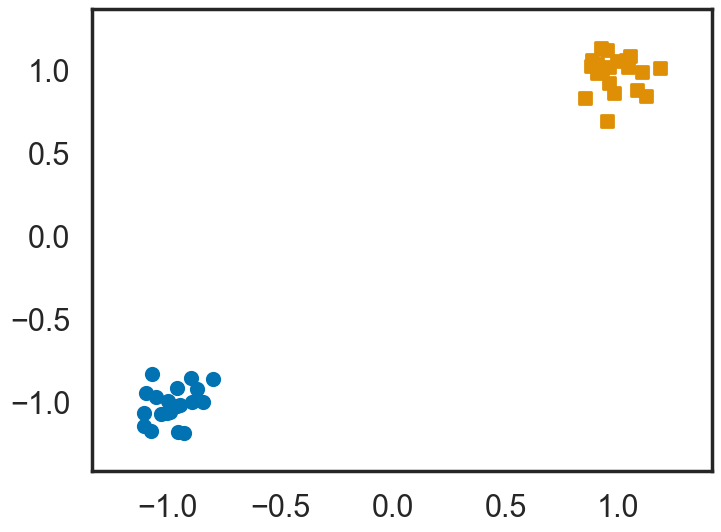

In [4]:
X1, y1 =rand_bi_gauss(n1=20, n2=20, mu1=[1, 1], mu2=[-1, -1], sigmas1=[0.1, 0.1],sigmas2=[0.1, 0.1])
print('X1',X1.shape,y1.shape)
fig, ax = plt.subplots()
plot_2d(X1, y1)

Les deux échantillons de classes sont non seulement éloignés mais ayant une variation moindre. Il faut les rapprocher.

X1 (40, 2) (40,)


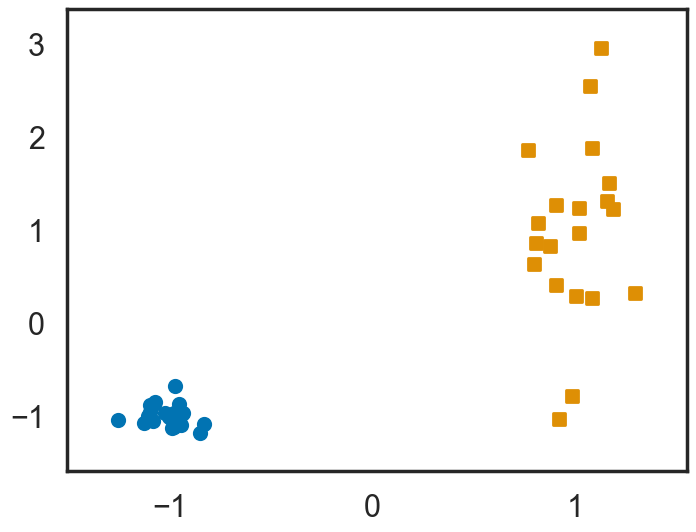

In [5]:
X1, y1 =rand_bi_gauss(n1=20, n2=20, mu1=[1, 1], mu2=[-1, -1], sigmas1=[0.1, 0.9],sigmas2=[0.1, 0.1])
print('X1',X1.shape,y1.shape)
fig, ax = plt.subplots()
plot_2d( X1, y1)

X1 (40, 2) (40,)


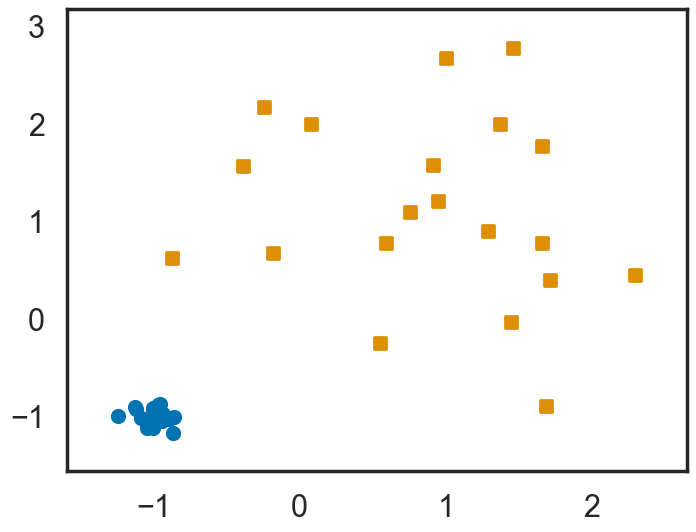

In [6]:
X1, y1 =rand_bi_gauss(n1=20, n2=20, mu1=[1, 1], mu2=[-1, -1], sigmas1=[0.9, 0.9],sigmas2=[0.1, 0.1])
print('X1',X1.shape,y1.shape)
fig, ax = plt.subplots()
plot_2d(X1, y1)

X1 (40, 2) (40,)


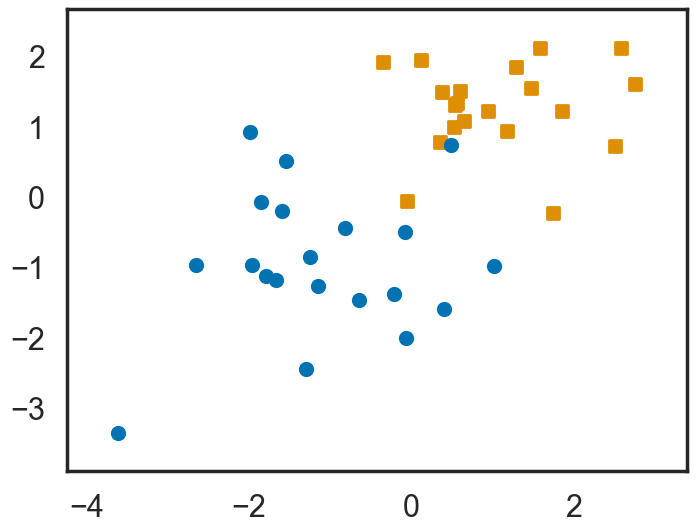

In [7]:
X1, y1 =rand_bi_gauss(n1=20, n2=20, mu1=[1, 1], mu2=[-1, -1], sigmas1=[0.9, 0.9],sigmas2=[0.9, 0.9])
print('X1',X1.shape,y1.shape)
fig, ax = plt.subplots()
plot_2d(X1, y1)

La fonction rand_bi_gauss renvoie deux données distribuées normales dont : 
- la taille = 20 ; 
- moyenne de la première échantillon est égale à -1 et -1 dans une dimension deux. L'autre 1 et 1. Ce sont des centres de la distributions 
- Chaque distribution a aussi son écart-type. 
La seconde variable de sortie est la répartition des données en classes.

In [8]:
# Création de données avec les deux autres fonctions
X2, y2 = rand_clown(n1=50, n2=50, sigma1=1, sigma2=5)
print('X2',X2.shape,y2.shape)

X3, y3 = rand_checkers(n1=150, n2=150)
print('X3',X3.shape,y3.shape)

X2 (100, 2) (100,)
X3 (288, 2) (288,)


### 1.2.2. Schéma des graphiques

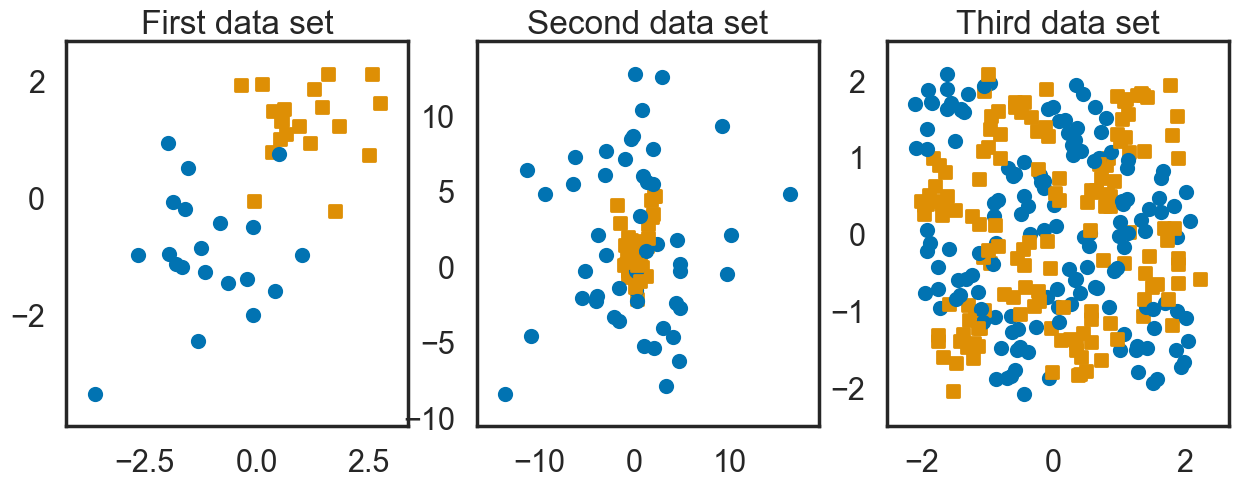

In [9]:
plt.close("all")
plt.figure(1, figsize=(15, 5))
plt.subplot(131)
plt.title('First data set')
plot_2d(X1, y1)
plt.subplot(132)
plt.title('Second data set')
plot_2d(X2, y2)
plt.subplot(133)
plt.title('Third data set')
plot_2d(X3, y3)
plt.show()

In [10]:
# Sauvegarder
X_bi_gauss = np.array(X1)
Y_bi_gauss = np.array(y1)
X_clown = np.array(X2)
Y_clown = np.array(y2)
X_chekers = np.array(X3)
Y_chekers = np.array(y3)

In [11]:
# Exporter
np.savez('jeu_de_donnees.npz',
         X_bi_gauss=X_bi_gauss,
         Y_bi_gauss=Y_bi_gauss,
         X_clown=X_clown,
         Y_clown=Y_clown,
         X_chekers=X_chekers,
         Y_chekers=Y_chekers)